**Transaction frequency Analysis**

**Importing Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

load dataset

In [3]:
df1 = pd.read_csv('cleaned_data.csv')

df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Transaction frequency measures how often transactions occur in a given time period.

In fraud detection:
Many transactions in a short time → suspicious

Step 1: Transaction Frequency

In [4]:
df1 = pd.read_csv('cleaned_data.csv')

# Count transactions occurring at same time
df1["TransactionFrequency"] = df1.groupby("Time")["Time"].transform("count")

print(df1[["Time", "TransactionFrequency"]].head())

   Time  TransactionFrequency
0   0.0                     2
1   0.0                     2
2   1.0                     2
3   1.0                     2
4   2.0                     2


Step 2: Fraud Trigger

Flag suspicious frequency:

In [5]:
df1["HighFrequency"] = df1["TransactionFrequency"] > 5

Step 3: Visualize Frequency

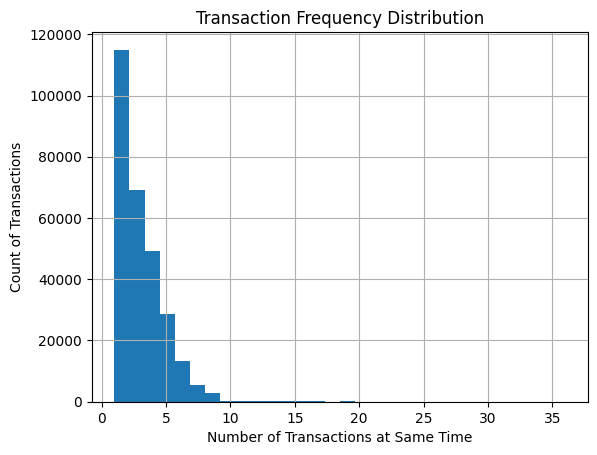

In [6]:
df1["TransactionFrequency"].hist(bins=30)
plt.title("Transaction Frequency Distribution")
plt.xlabel("Number of Transactions at Same Time")
plt.ylabel("Count of Transactions")
plt.show()

* Step 4: Customer / Account Risk Scoring

Risk scoring ranks customers or transactions by how suspicious they are.

In [7]:
# Start risk score
df1["RiskScore"] = 0

# Large transaction
df1.loc[df1["Amount"] > 2000, "RiskScore"] += 2

# Very large transaction
df1.loc[df1["Amount"] > 5000, "RiskScore"] += 3

# High transaction frequency
df1["TransactionFrequency"] = df1.groupby("Time")["Time"].transform("count")
df1.loc[df1["TransactionFrequency"] > 5, "RiskScore"] += 2

# Known fraud label (if exists)
if "Class" in df1.columns:
    df1.loc[df1["Class"] == 1, "RiskScore"] += 5

print(df1[["Amount", "TransactionFrequency", "RiskScore"]].head())

   Amount  TransactionFrequency  RiskScore
0  149.62                     2          0
1    2.69                     2          0
2  378.66                     2          0
3  123.50                     2          0
4   69.99                     2          0


**Transaction Amount Analysis**

Step 1:Transaction amount analysis helps identify unusual spending patterns, which are common in fraud cases.

In [8]:
print("Transaction Amount Statistics:")
print(df1["Amount"].describe())

Transaction Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


Step 2: Amount Distribution Chart

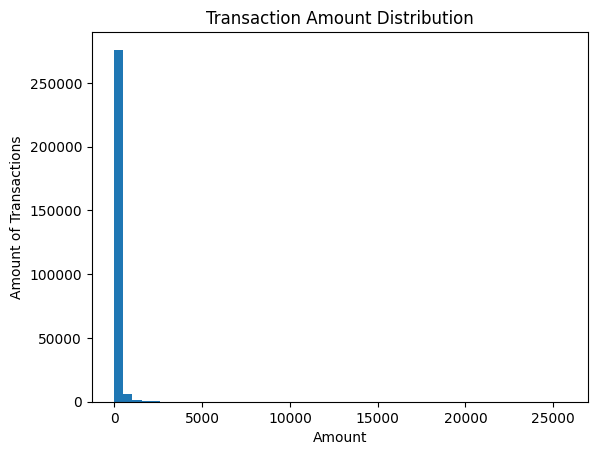

In [9]:
plt.hist(df1["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Amount of Transactions")
plt.show()

Step 3: Fraud vs Normal Amount Comparison

In [10]:
fraud = df1[df1["Class"] == 1]
normal = df1[df1["Class"] == 0]

print("Average Fraud Amount:", fraud["Amount"].mean())

Average Fraud Amount: 122.21132113821139


Step 4: Detect Large Transactions

In [11]:
df1["LargeTransaction"] = df1["Amount"] > 2000

Step 5: Amount Anomaly Detection

In [12]:
mean_amt = df1["Amount"].mean()
std_amt = df1["Amount"].std()

threshold = mean_amt + 3 * std_amt
df1["AmountAnomaly"] = df1["Amount"] > threshold

End 